# Evaluación Parcial N°1 — Fundamentos de Deep Learning
**Asignatura:** DLY0100 — Deep Learning  
**Dataset:** CIFAR-10  
**Framework:** TensorFlow / Keras

---

## Descripción del problema

El objetivo de esta evaluación es implementar una **Red Neuronal Artificial Multicapa (MLP)** para resolver un problema de **clasificación de imágenes** usando el dataset CIFAR-10.

**CIFAR-10** es un dataset estándar en Deep Learning compuesto por 60.000 imágenes a color de 32×32 píxeles, distribuidas en **10 clases**:

| ID | Clase     | ID | Clase   |
|----|-----------|----|---------|
| 0  | Avión     | 5  | Perro   |
| 1  | Auto      | 6  | Rana    |
| 2  | Pájaro    | 7  | Caballo |
| 3  | Gato      | 8  | Barco   |
| 4  | Venado    | 9  | Camión  |

**Objetivo del modelo:** Dado una imagen de 32×32 píxeles RGB, predecir correctamente a cuál de las 10 clases pertenece.

---
## 0. Importaciones y configuración

Importamos las librerías necesarias para el proyecto. Usamos **TensorFlow/Keras** para construir y entrenar la red neuronal, **NumPy** para operaciones numéricas, **Matplotlib** y **Seaborn** para visualización, y **scikit-learn** para calcular las métricas de evaluación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Fijamos semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'NumPy version: {np.__version__}')

TensorFlow version: 2.20.0
NumPy version: 2.0.2


---
## 1. Carga y preprocesamiento de datos

### 1.1 Carga del dataset

CIFAR-10 está disponible directamente en Keras. Al ejecutar `load_data()`, Keras descarga el dataset automáticamente (solo la primera vez) y lo divide en:
- **Conjunto de entrenamiento:** 50.000 imágenes
- **Conjunto de prueba:** 10.000 imágenes

Cada imagen tiene dimensiones `(32, 32, 3)` — 32 píxeles de alto, 32 de ancho, 3 canales de color (RGB).

In [2]:
# Cargamos CIFAR-10 directamente desde Keras
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

# Nombres de las clases
CLASES = ['Avión', 'Auto', 'Pájaro', 'Gato', 'Venado',
          'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']
N_CLASES = len(CLASES)

print('=== Información del dataset ===')
print(f'X_train: {X_train_raw.shape}  →  {X_train_raw.shape[0]} imágenes de {X_train_raw.shape[1]}×{X_train_raw.shape[2]} px, {X_train_raw.shape[3]} canales')
print(f'X_test:  {X_test_raw.shape}  →  {X_test_raw.shape[0]} imágenes')
print(f'Rango de valores de píxeles: [{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'Clases: {CLASES}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
=== Información del dataset ===
X_train: (50000, 32, 32, 3)  →  50000 imágenes de 32×32 px, 3 canales
X_test:  (10000, 32, 32, 3)  →  10000 imágenes
Rango de valores de píxeles: [0, 255]
Clases: ['Avión', 'Auto', 'Pájaro', 'Gato', 'Venado', 'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']


### 1.2 Visualización de ejemplos del dataset

Antes de preprocesar, visualizamos algunas imágenes para entender qué tipo de datos tenemos.

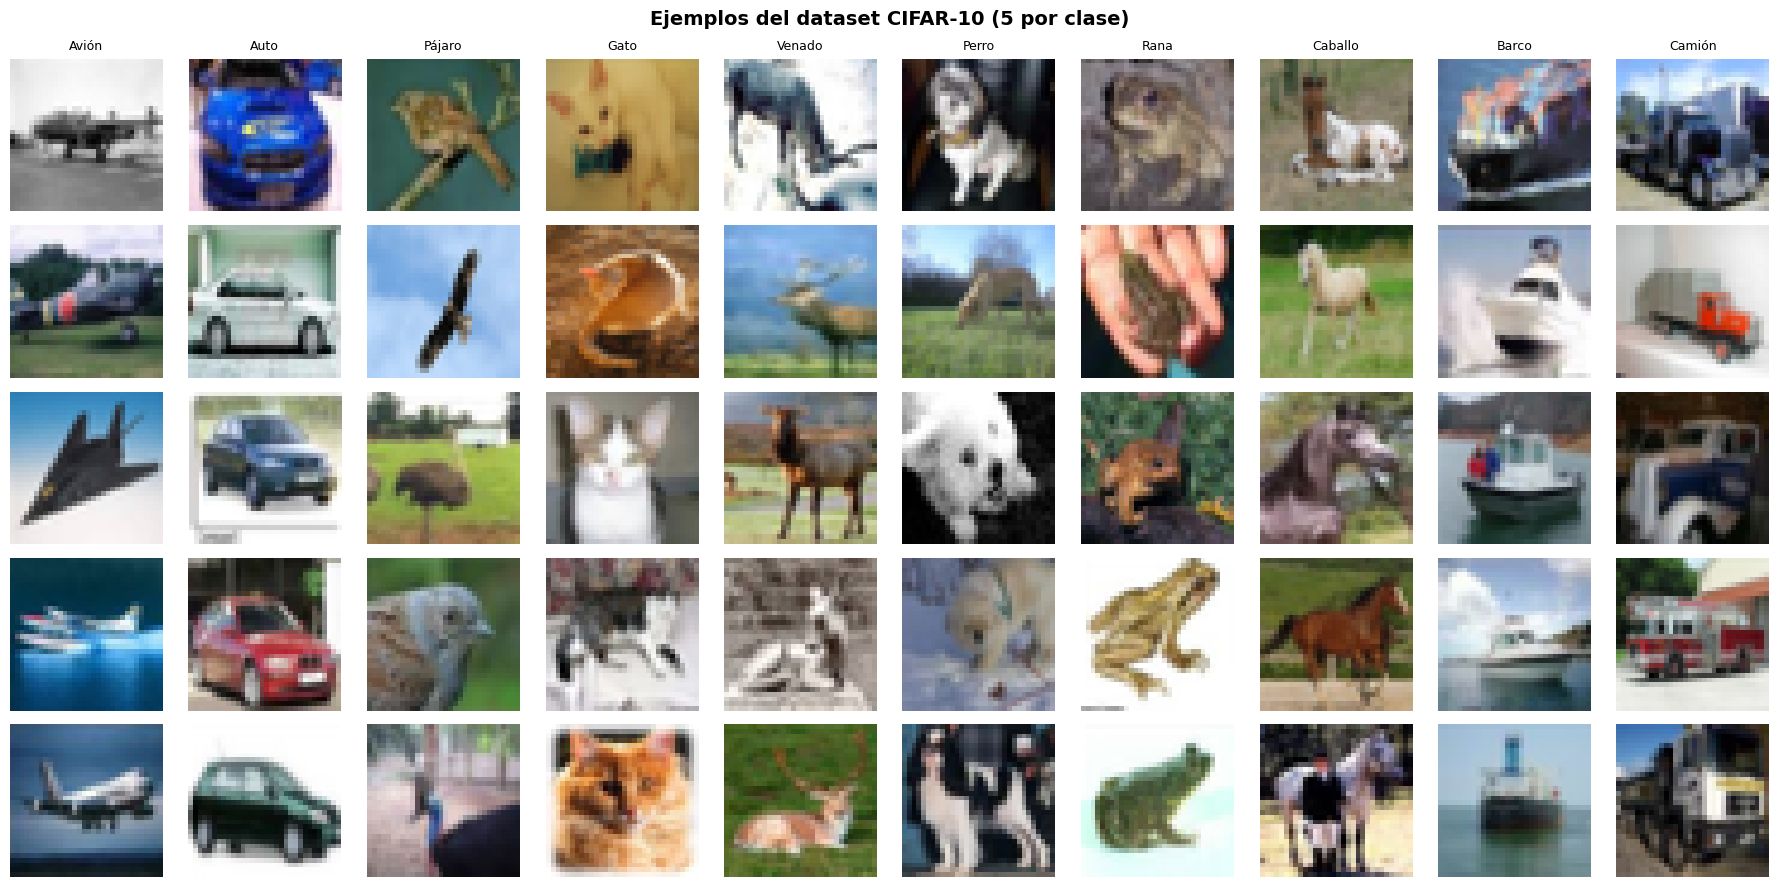

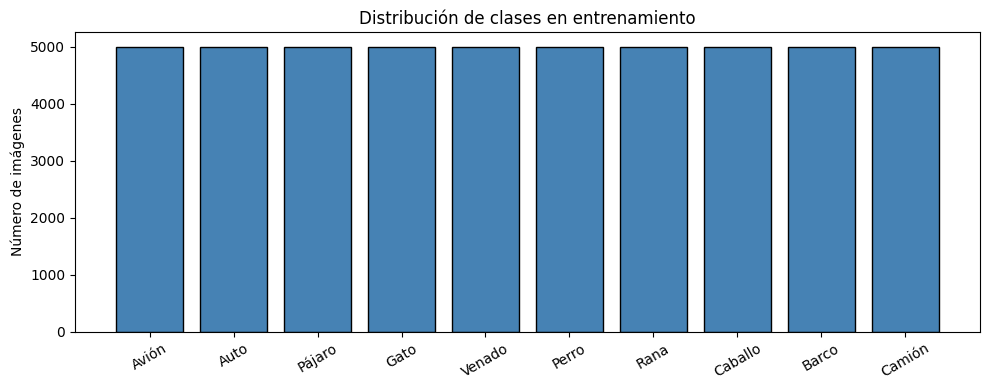

Dataset balanceado: cada clase tiene exactamente 5000 imágenes en entrenamiento.


In [3]:
# Mostramos una grilla de 5x10 con un ejemplo por clase
fig, axs = plt.subplots(5, 10, figsize=(18, 9))
fig.suptitle('Ejemplos del dataset CIFAR-10 (5 por clase)', fontsize=14, fontweight='bold')

for col, clase in enumerate(CLASES):
    # Obtenemos índices de esa clase
    indices = np.where(y_train_raw.flatten() == col)[0]
    muestras = np.random.choice(indices, 5, replace=False)
    for row, idx in enumerate(muestras):
        axs[row, col].imshow(X_train_raw[idx])
        axs[row, col].axis('off')
        if row == 0:
            axs[row, col].set_title(clase, fontsize=9)

plt.tight_layout()
plt.show()

# Distribución de clases en el conjunto de entrenamiento
fig, ax = plt.subplots(figsize=(10, 4))
conteos = np.bincount(y_train_raw.flatten())
ax.bar(CLASES, conteos, color='steelblue', edgecolor='black')
ax.set_title('Distribución de clases en entrenamiento')
ax.set_ylabel('Número de imágenes')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('Dataset balanceado: cada clase tiene exactamente', conteos[0], 'imágenes en entrenamiento.')

### 1.3 Preprocesamiento de datos

Aplicamos dos transformaciones fundamentales:

**1. Aplanado (reshape):** Un MLP recibe vectores 1D como entrada, no matrices 3D. Cada imagen de `(32, 32, 3)` se convierte en un vector de `32 × 32 × 3 = 3.072` valores.

**2. Normalización:** Los valores de los píxeles van de 0 a 255. Al dividir por 255, los llevamos al rango `[0, 1]`. Esto es crítico porque:
- Estabiliza el entrenamiento (gradientes más suaves)
- Acelera la convergencia
- Evita que neuronas se saturen en funciones como Sigmoid

**3. One-Hot Encoding:** Las etiquetas son números (0-9). Las convertimos a vectores binarios de 10 dimensiones para usar `categorical_crossentropy` como función de pérdida.

In [4]:
N_TRAIN = X_train_raw.shape[0]  # 50000
N_TEST  = X_test_raw.shape[0]   # 10000
N_INPUT = 32 * 32 * 3           # 3072 neuronas de entrada

# 1. Aplanar: (50000, 32, 32, 3) → (50000, 3072)
X_train = X_train_raw.reshape(N_TRAIN, N_INPUT)
X_test  = X_test_raw.reshape(N_TEST, N_INPUT)

# 2. Normalizar: valores de [0, 255] → [0.0, 1.0]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

# 3. One-Hot Encoding de las etiquetas
Y_train = keras.utils.to_categorical(y_train_raw, N_CLASES)
Y_test  = keras.utils.to_categorical(y_test_raw, N_CLASES)

print('=== Datos preprocesados ===')
print(f'X_train: {X_train.shape}  |  rango: [{X_train.min():.2f}, {X_train.max():.2f}]')
print(f'X_test:  {X_test.shape}   |  rango: [{X_test.min():.2f}, {X_test.max():.2f}]')
print(f'Y_train: {Y_train.shape}  |  ejemplo: y_train_raw[0]={y_train_raw[0][0]} → Y_train[0]={Y_train[0]}')
print(f'Y_test:  {Y_test.shape}')

=== Datos preprocesados ===
X_train: (50000, 3072)  |  rango: [0.00, 1.00]
X_test:  (10000, 3072)   |  rango: [0.00, 1.00]
Y_train: (50000, 10)  |  ejemplo: y_train_raw[0]=6 → Y_train[0]=[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Y_test:  (10000, 10)


---
## 2. Funciones de activación, error y salida

### 2.1 Descripción de las funciones utilizadas

Las funciones de activación determinan si una neurona se activa o no, introduciendo **no-linealidad** en la red. Sin ellas, una red de múltiples capas sería equivalente a una sola capa lineal.

#### Funciones en capas ocultas:
| Función | Fórmula | Rango de salida | Uso |
|---------|---------|-----------------|-----|
| **ReLU** | `max(0, x)` | [0, ∞) | Default en capas ocultas |
| **Sigmoid** | `1/(1+e^-x)` | (0, 1) | Problemas binarios |
| **Tanh** | `(e^x - e^-x)/(e^x + e^-x)` | (-1, 1) | Alternativa a Sigmoid |

#### Función en capa de salida:
- **Softmax:** Convierte los logits en una distribución de probabilidad sobre las 10 clases. La suma de todas las salidas siempre es 1.

#### Función de error (pérdida):
- **Categorical Crossentropy:** Mide qué tan diferente es la distribución predicha de la real. Es la función estándar para clasificación multi-clase con one-hot encoding.

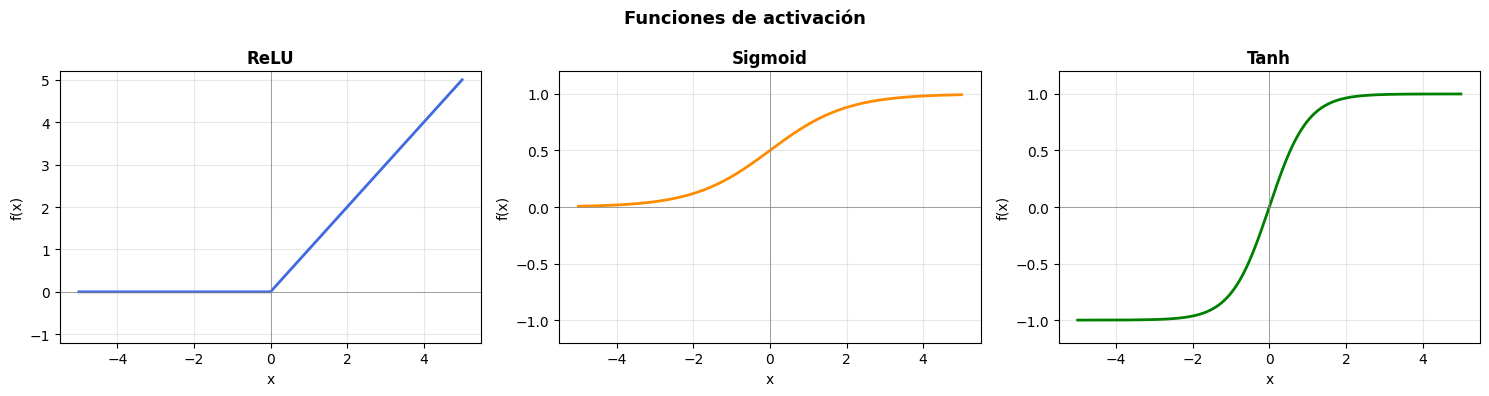

In [5]:
# Visualizamos las funciones de activación
x = np.linspace(-5, 5, 300)

relu    = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh_f  = np.tanh(x)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Funciones de activación', fontsize=13, fontweight='bold')

for ax, (nombre, valores, color) in zip(axs, [
    ('ReLU', relu, 'royalblue'),
    ('Sigmoid', sigmoid, 'darkorange'),
    ('Tanh', tanh_f, 'green')
]):
    ax.plot(x, valores, color=color, linewidth=2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(nombre, fontweight='bold')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.2, 1.2 if nombre != 'ReLU' else 5.2)

plt.tight_layout()
plt.show()

### 2.2 Comparación de funciones de activación

Entrenamos el mismo modelo con diferentes funciones de activación en las capas ocultas, manteniendo **todo lo demás constante**, para aislar el efecto de la función de activación.

In [6]:
def construir_modelo(activacion='relu', n_capas=2, n_neuronas=256):
    """Construye un MLP con la activación especificada."""
    model = keras.Sequential(name=f'MLP_{activacion}')
    model.add(layers.Input(shape=(N_INPUT,)))
    for _ in range(n_capas):
        model.add(layers.Dense(n_neuronas, activation=activacion))
    model.add(layers.Dense(N_CLASES, activation='softmax'))
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        #al pasar adam a travez de keras, el learning rate por defecto
        #en este caso sera 0.001
        metrics=['accuracy']
    )
    return model

# Parametros de comparacion, iniciales 15, 128
EPOCAS_COMP = 15
BATCH_COMP  = 128

activaciones = ['relu', 'sigmoid', 'tanh']
historiales_act  = {}
resultados_act   = []

for act in activaciones:
    print(f'\nEntrenando con activación: {act.upper()}')
    model = construir_modelo(activacion=act)
    hist = model.fit(
        X_train, Y_train,
        epochs=EPOCAS_COMP,
        batch_size=BATCH_COMP,
        validation_data=(X_test, Y_test),
        verbose=1
    )
    historiales_act[act] = hist
    val_acc  = max(hist.history['val_accuracy'])
    val_loss = min(hist.history['val_loss'])
    resultados_act.append({'Activación': act.upper(), 'Val Accuracy': round(val_acc, 4), 'Val Loss': round(val_loss, 4)})
    print(f'  → Mejor val_accuracy: {val_acc:.4f} | Mejor val_loss: {val_loss:.4f}')


Entrenando con activación: RELU
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.3282 - loss: 1.8699 - val_accuracy: 0.3619 - val_loss: 1.7387
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.3999 - loss: 1.6809 - val_accuracy: 0.4008 - val_loss: 1.6618
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.4287 - loss: 1.5978 - val_accuracy: 0.4341 - val_loss: 1.5803
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.4521 - loss: 1.5380 - val_accuracy: 0.4427 - val_loss: 1.5519
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.4658 - loss: 1.4945 - val_accuracy: 0.4560 - val_loss: 1.5247
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.4800 - loss: 1.4583 - val_accuracy: 0.4623 - val_loss: 1.5037
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.4881 - loss: 1.4349 - val_accuracy: 0.4733 - val_loss: 1.4746
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accu

=== Tabla comparativa — Funciones de activación ===
Activación  Val Accuracy  Val Loss
      RELU        0.4959    1.4300
   SIGMOID        0.4810    1.4598
      TANH        0.4417    1.5473


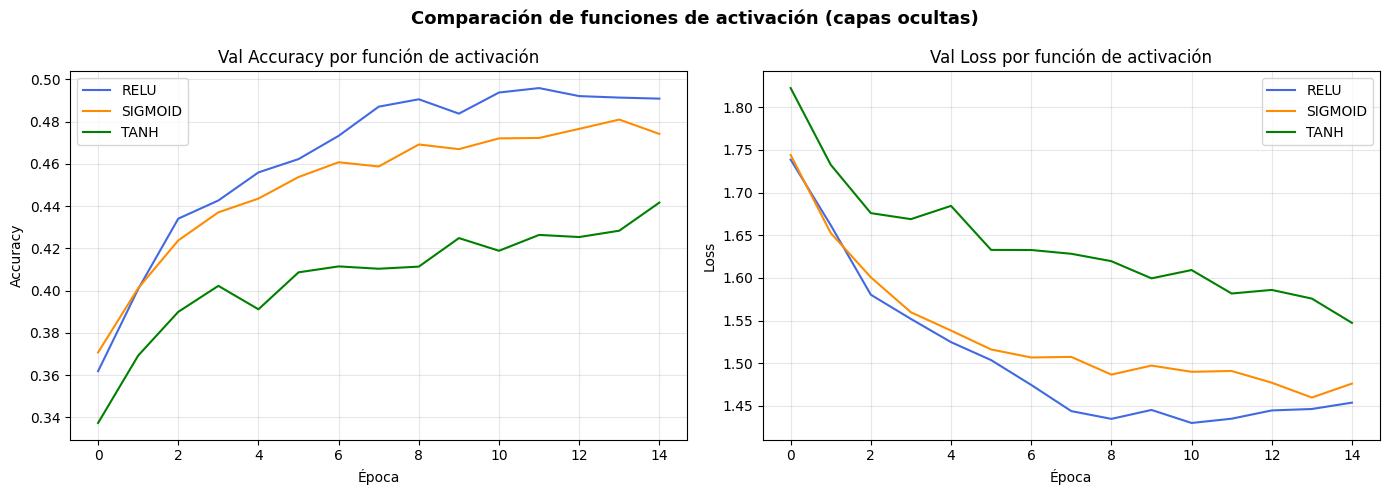

In [7]:
# Tabla comparativa
df_act = pd.DataFrame(resultados_act)
print('=== Tabla comparativa — Funciones de activación ===')
print(df_act.to_string(index=False))

# Gráfico comparativo
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
colores = {'relu': 'royalblue', 'sigmoid': 'darkorange', 'tanh': 'green'}

for act in activaciones:
    h = historiales_act[act]
    axs[0].plot(h.history['val_accuracy'],  label=act.upper(), color=colores[act])
    axs[1].plot(h.history['val_loss'],      label=act.upper(), color=colores[act])

axs[0].set_title('Val Accuracy por función de activación');  axs[0].set_xlabel('Época'); axs[0].set_ylabel('Accuracy'); axs[0].legend(); axs[0].grid(True, alpha=0.3)
axs[1].set_title('Val Loss por función de activación');      axs[1].set_xlabel('Época'); axs[1].set_ylabel('Loss');     axs[1].legend(); axs[1].grid(True, alpha=0.3)
plt.suptitle('Comparación de funciones de activación (capas ocultas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Justificación de la función elegida

De los experimentos anteriores podemos observar que:

- **ReLU** converge más rápido y alcanza mayor accuracy. Esto ocurre porque ReLU evita el problema del **vanishing gradient** que sufren Sigmoid y Tanh: cuando x es grande, el gradiente de Sigmoid tiende a 0 y el aprendizaje se detiene.
- **Sigmoid** converge lento y queda atrapada en valores bajos de accuracy.
- **Tanh** es mejor que Sigmoid pero inferior a ReLU en este problema.

**Decisión:** Usaremos **ReLU** en todas las capas ocultas y **Softmax** en la capa de salida (estándar para clasificación multi-clase).

**Función de pérdida:** `categorical_crossentropy`, que es la adecuada cuando las etiquetas están en formato one-hot y la salida usa Softmax.

---
## 3. Definición del modelo MLP

### 3.1 Arquitectura del modelo

Construimos un MLP con la siguiente arquitectura:

- **Capa de entrada:** 3.072 neuronas (una por píxel×canal)
- **Capa oculta 1:** 512 neuronas, activación ReLU
- **Capa oculta 2:** 256 neuronas, activación ReLU
- **Capa oculta 3:** 128 neuronas, activación ReLU
- **Capa de salida:** 10 neuronas, activación Softmax

La arquitectura decreciente (512→256→128) es una práctica común que permite que la red aprenda representaciones cada vez más abstractas.

In [8]:
def construir_modelo_base():
    model = keras.Sequential([
        layers.Input(shape=(N_INPUT,)),
        layers.Dense(512, activation='relu', name='capa_oculta_1'),
        layers.Dense(256, activation='relu', name='capa_oculta_2'),
        layers.Dense(128, activation='relu', name='capa_oculta_3'),
        layers.Dense(N_CLASES, activation='softmax', name='capa_salida')
    ], name='MLP_base')

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

modelo_base = construir_modelo_base()
modelo_base.summary()

Model: "MLP_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_3 (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_salida (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Entrenamiento del modelo base

Entrenamos el modelo con los parámetros iniciales:
- **Épocas:** 30
- **Batch size:** 128
- **Optimizador:** Adam con lr=0.001

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.3152 - loss: 1.8968 - val_accuracy: 0.3712 - val_loss: 1.7356
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.3989 - loss: 1.6837 - val_accuracy: 0.4082 - val_loss: 1.6505
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.4286 - loss: 1.5981 - val_accuracy: 0.4356 - val_loss: 1.5690
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.4472 - loss: 1.5453 - val_accuracy: 0.4606 - val_loss: 1.5158
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.4639 - loss: 1.4968 - val_accuracy: 0.4791 - val_loss: 1.4783
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.4778 - loss: 1.4577 - val_accuracy: 0.4764 - val_loss: 1.4699
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.4887 - loss: 1.4221 - val_accuracy: 0.4766 - val_loss: 1.4778
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.5005 - loss: 1.3947 - 

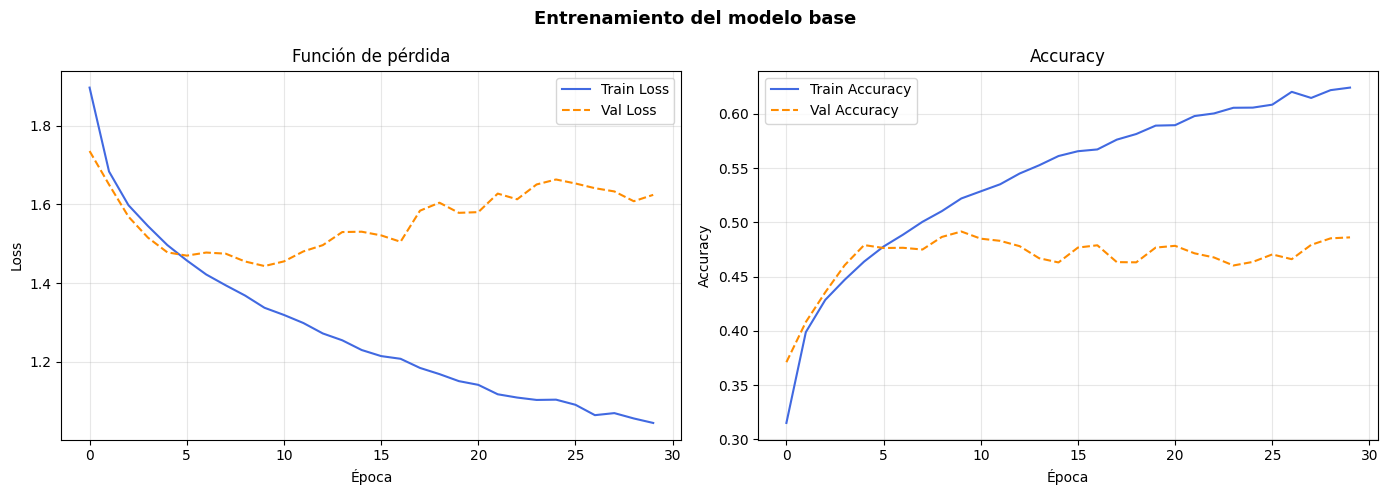


Modelo base → Test Loss: 1.6243 | Test Accuracy: 0.4862


In [9]:
np.random.seed(42)
tf.random.set_seed(42)

hist_base = modelo_base.fit(
    X_train, Y_train,
    epochs=30,
    batch_size=128,
    validation_data=(X_test, Y_test),
    verbose=1
)

# Gráfica del entrenamiento base
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Entrenamiento del modelo base', fontsize=13, fontweight='bold')

axs[0].plot(hist_base.history['loss'],     label='Train Loss',     color='royalblue')
axs[0].plot(hist_base.history['val_loss'], label='Val Loss',       color='darkorange', linestyle='--')
axs[0].set_title('Función de pérdida'); axs[0].set_xlabel('Época'); axs[0].set_ylabel('Loss'); axs[0].legend(); axs[0].grid(True, alpha=0.3)

axs[1].plot(hist_base.history['accuracy'],     label='Train Accuracy', color='royalblue')
axs[1].plot(hist_base.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linestyle='--')
axs[1].set_title('Accuracy'); axs[1].set_xlabel('Época'); axs[1].set_ylabel('Accuracy'); axs[1].legend(); axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

loss_b, acc_b = modelo_base.evaluate(X_test, Y_test, verbose=0)
print(f'\nModelo base → Test Loss: {loss_b:.4f} | Test Accuracy: {acc_b:.4f}')

---
## 4. Experimentos con hiperparámetros

Analizamos el impacto de cada hiperparámetro clave variando **un parámetro a la vez**, manteniendo el resto constante. Esto nos permite aislar el efecto de cada variable.

### 4.1 Experimento 1 — Learning Rate

El **learning rate** (tasa de aprendizaje) controla qué tan grande es el paso que da el optimizador en cada actualización de pesos. Un valor muy alto puede hacer que el modelo diverja; uno muy bajo puede hacer el entrenamiento extremadamente lento.


Entrenando con lr=0.01
  → Mejor val_accuracy: 0.3262

Entrenando con lr=0.001
  → Mejor val_accuracy: 0.4907

Entrenando con lr=0.0001
  → Mejor val_accuracy: 0.5053

=== Tabla comparativa — Learning Rate ===
 Learning Rate  Val Accuracy  Val Loss
        0.0100        0.3262    1.8259
        0.0010        0.4907    1.4651
        0.0001        0.5053    1.3952


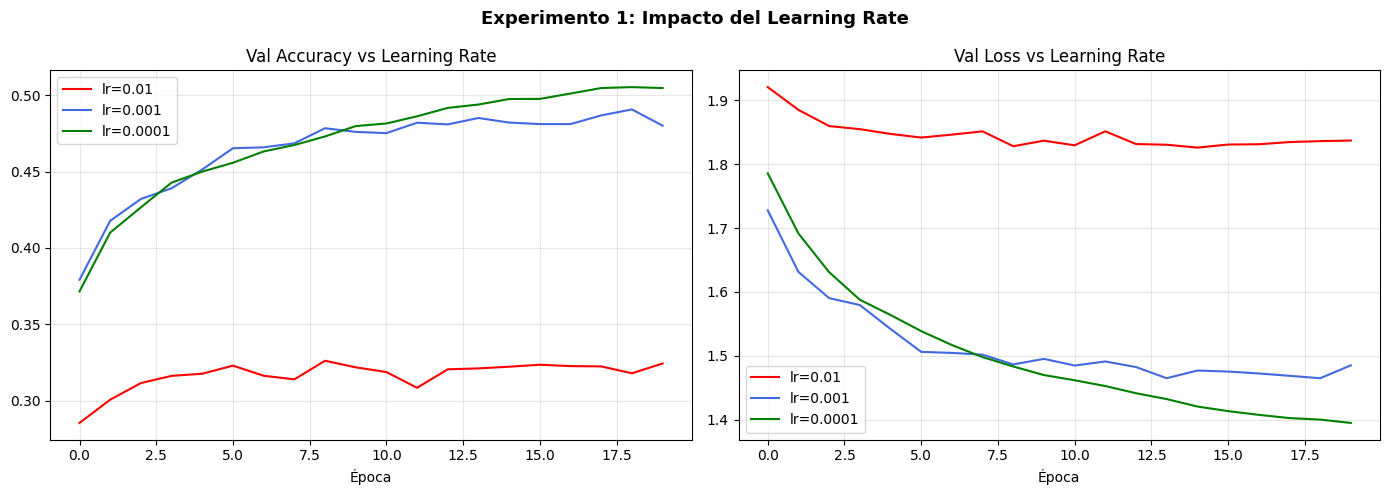

In [10]:
learning_rates = [0.01, 0.001, 0.0001]
hist_lr = {}
resultados_lr = []

for lr in learning_rates:
    print(f'\nEntrenando con lr={lr}')
    np.random.seed(42); tf.random.set_seed(42)
    m = keras.Sequential([
        layers.Input(shape=(N_INPUT,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(N_CLASES, activation='softmax')
    ])
    m.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adam(lr), metrics=['accuracy'])
    h = m.fit(X_train, Y_train, epochs=20, batch_size=128, validation_data=(X_test, Y_test), verbose=0)
    hist_lr[lr] = h
    val_acc  = max(h.history['val_accuracy'])
    val_loss = min(h.history['val_loss'])
    resultados_lr.append({'Learning Rate': lr, 'Val Accuracy': round(val_acc, 4), 'Val Loss': round(val_loss, 4)})
    print(f'  → Mejor val_accuracy: {val_acc:.4f}')

# Tabla y gráfico
print('\n=== Tabla comparativa — Learning Rate ===')
print(pd.DataFrame(resultados_lr).to_string(index=False))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
colores_lr = {0.01: 'red', 0.001: 'royalblue', 0.0001: 'green'}
for lr in learning_rates:
    axs[0].plot(hist_lr[lr].history['val_accuracy'], label=f'lr={lr}', color=colores_lr[lr])
    axs[1].plot(hist_lr[lr].history['val_loss'],     label=f'lr={lr}', color=colores_lr[lr])

axs[0].set_title('Val Accuracy vs Learning Rate'); axs[0].set_xlabel('Época'); axs[0].legend(); axs[0].grid(True, alpha=0.3)
axs[1].set_title('Val Loss vs Learning Rate');     axs[1].set_xlabel('Época'); axs[1].legend(); axs[1].grid(True, alpha=0.3)
plt.suptitle('Experimento 1: Impacto del Learning Rate', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.2 Experimento 2 — Batch Size

El **batch size** define cuántas muestras se procesan antes de cada actualización de pesos. Batches más pequeños generan más actualizaciones (ruido útil) pero son más lentos; batches grandes son más rápidos pero pueden converger a mínimos peores.


Entrenando con batch_size=32
  → Mejor val_accuracy: 0.4845

Entrenando con batch_size=128
  → Mejor val_accuracy: 0.4956

Entrenando con batch_size=512
  → Mejor val_accuracy: 0.4923

=== Tabla comparativa — Batch Size ===
 Batch Size  Val Accuracy  Val Loss
         32        0.4845    1.4591
        128        0.4956    1.4418
        512        0.4923    1.4286


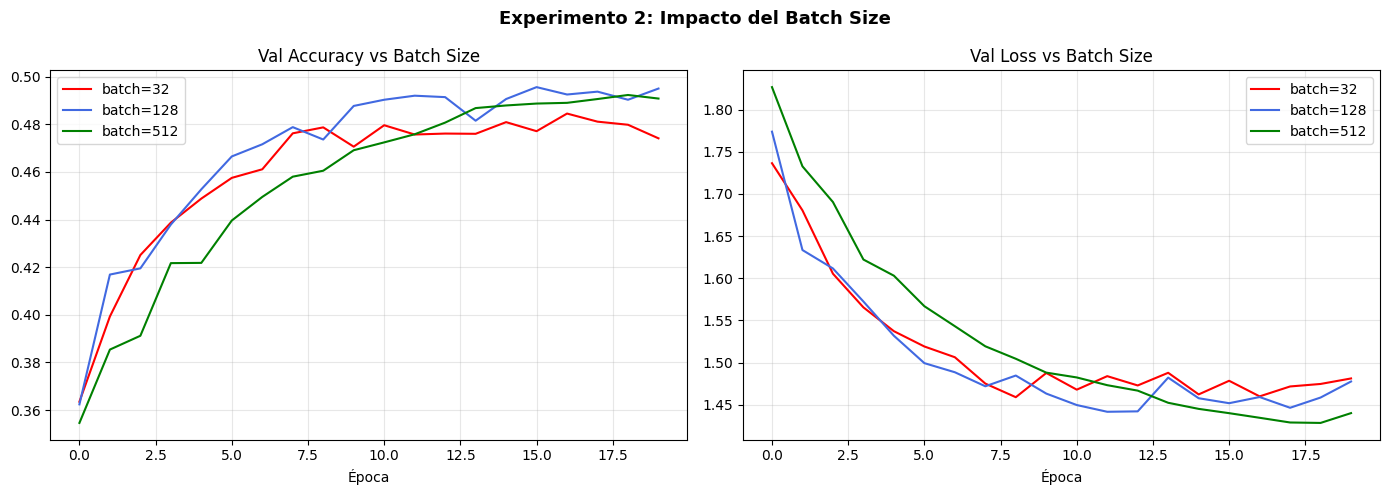

In [11]:
batch_sizes = [32, 128, 512]
hist_bs = {}
resultados_bs = []

for bs in batch_sizes:
    print(f'\nEntrenando con batch_size={bs}')
    np.random.seed(42); tf.random.set_seed(42)
    m = keras.Sequential([
        layers.Input(shape=(N_INPUT,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(N_CLASES, activation='softmax')
    ])
    m.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adam(0.001), metrics=['accuracy'])
    h = m.fit(X_train, Y_train, epochs=20, batch_size=bs, validation_data=(X_test, Y_test), verbose=0)
    hist_bs[bs] = h
    val_acc  = max(h.history['val_accuracy'])
    val_loss = min(h.history['val_loss'])
    resultados_bs.append({'Batch Size': bs, 'Val Accuracy': round(val_acc, 4), 'Val Loss': round(val_loss, 4)})
    print(f'  → Mejor val_accuracy: {val_acc:.4f}')

print('\n=== Tabla comparativa — Batch Size ===')
print(pd.DataFrame(resultados_bs).to_string(index=False))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
colores_bs = {32: 'red', 128: 'royalblue', 512: 'green'}
for bs in batch_sizes:
    axs[0].plot(hist_bs[bs].history['val_accuracy'], label=f'batch={bs}', color=colores_bs[bs])
    axs[1].plot(hist_bs[bs].history['val_loss'],     label=f'batch={bs}', color=colores_bs[bs])

axs[0].set_title('Val Accuracy vs Batch Size'); axs[0].set_xlabel('Época'); axs[0].legend(); axs[0].grid(True, alpha=0.3)
axs[1].set_title('Val Loss vs Batch Size');     axs[1].set_xlabel('Época'); axs[1].legend(); axs[1].grid(True, alpha=0.3)
plt.suptitle('Experimento 2: Impacto del Batch Size', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.3 Experimento 3 — Número de épocas

Analizamos el comportamiento del modelo a lo largo de las épocas para identificar cuándo converge y detectar señales de **overfitting** (cuando el val_loss comienza a subir mientras el train_loss sigue bajando).

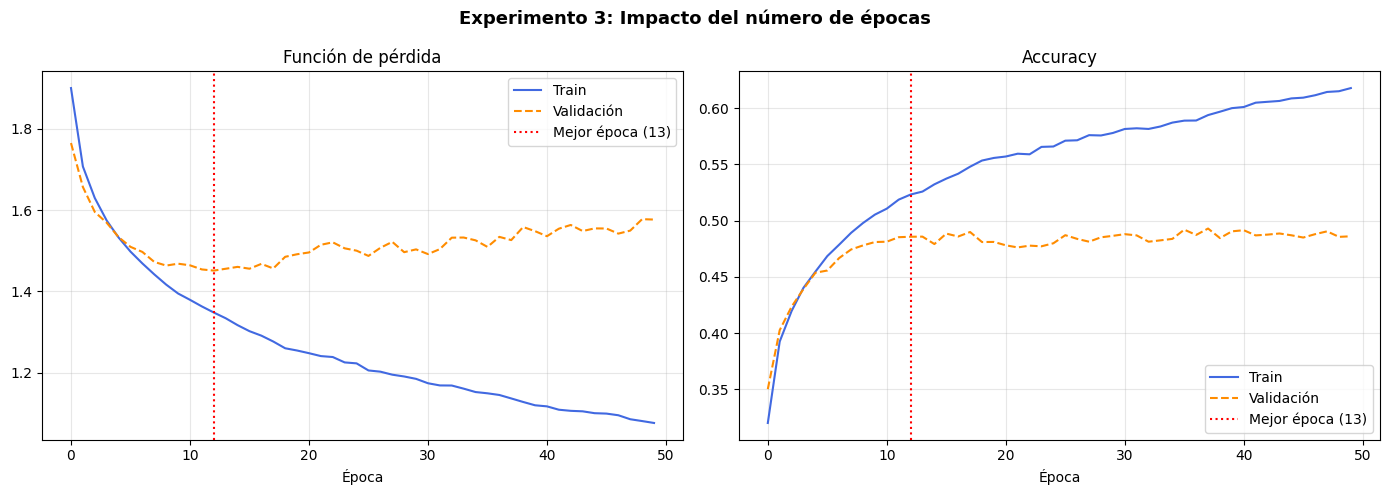

Mejor época (menor val_loss): 13
Observación: después de la época 13 el val_loss comienza a subir → señal de overfitting.


In [12]:
np.random.seed(42); tf.random.set_seed(42)
m_epocas = keras.Sequential([
    layers.Input(shape=(N_INPUT,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(N_CLASES, activation='softmax')
])
m_epocas.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adam(0.001), metrics=['accuracy'])
hist_epocas = m_epocas.fit(X_train, Y_train, epochs=50, batch_size=128, validation_data=(X_test, Y_test), verbose=0)

# Detectar overfitting
val_loss_hist = hist_epocas.history['val_loss']
mejor_epoca   = np.argmin(val_loss_hist) + 1

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Experimento 3: Impacto del número de épocas', fontsize=13, fontweight='bold')

for ax, key_train, key_val, titulo in [
    (axs[0], 'loss', 'val_loss', 'Función de pérdida'),
    (axs[1], 'accuracy', 'val_accuracy', 'Accuracy')
]:
    ax.plot(hist_epocas.history[key_train], label='Train',      color='royalblue')
    ax.plot(hist_epocas.history[key_val],   label='Validación', color='darkorange', linestyle='--')
    ax.axvline(mejor_epoca - 1, color='red', linestyle=':', label=f'Mejor época ({mejor_epoca})')
    ax.set_title(titulo); ax.set_xlabel('Época'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Mejor época (menor val_loss): {mejor_epoca}')
print('Observación: después de la época', mejor_epoca, 'el val_loss comienza a subir → señal de overfitting.')

### 4.4 Experimento 4 — Profundidad de la red (número de capas)

Más allá de learning rate y batch size, la **arquitectura** (número y tamaño de capas) es uno de los hiperparámetros más importantes. Comparamos redes con 1, 2 y 3 capas ocultas manteniendo el mismo número total de neuronas aproximado.


Entrenando: 1 capa (512)
  → Val Acc: 0.4784 | Parámetros: 1,578,506

Entrenando: 2 capas (256-128)
  → Val Acc: 0.4884 | Parámetros: 820,874

Entrenando: 3 capas (256-128-64)
  → Val Acc: 0.4785 | Parámetros: 828,490

=== Tabla comparativa — Arquitecturas ===
        Arquitectura  Parámetros  Val Accuracy  Val Loss
        1 capa (512)     1578506        0.4784    1.4757
   2 capas (256-128)      820874        0.4884    1.4605
3 capas (256-128-64)      828490        0.4785    1.4954


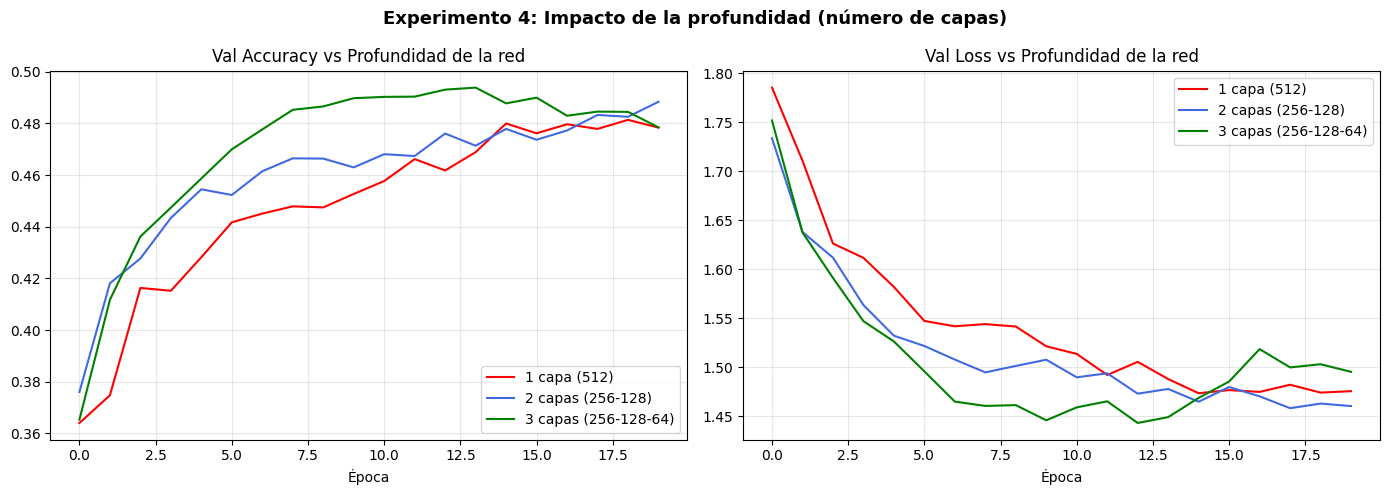

In [13]:
# Experimento: Número de capas ocultas
arquitecturas = {
    '1 capa (512)':           [512],
    '2 capas (256-128)':      [256, 128],
    '3 capas (256-128-64)':   [256, 128, 64],
}

hist_arch = {}
resultados_arch = []

for nombre, capas in arquitecturas.items():
    print(f'\nEntrenando: {nombre}')
    np.random.seed(42); tf.random.set_seed(42)

    m = keras.Sequential(name=f'arch_{len(capas)}_capas')
    m.add(layers.Input(shape=(N_INPUT,)))
    for n in capas:
        m.add(layers.Dense(n, activation='relu'))
    m.add(layers.Dense(N_CLASES, activation='softmax'))

    m.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(0.001),
        metrics=['accuracy']
    )

    h = m.fit(X_train, Y_train, epochs=20, batch_size=128,
              validation_data=(X_test, Y_test), verbose=0)

    hist_arch[nombre] = h
    loss, acc = m.evaluate(X_test, Y_test, verbose=0)
    resultados_arch.append({
        'Arquitectura': nombre,
        'Parámetros': m.count_params(),
        'Val Accuracy': round(acc, 4),
        'Val Loss': round(loss, 4)
    })
    print(f'  → Val Acc: {acc:.4f} | Parámetros: {m.count_params():,}')

df_arch = pd.DataFrame(resultados_arch)
print('\n=== Tabla comparativa — Arquitecturas ===')
print(df_arch.to_string(index=False))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
colores_arch = list({'1 capa (512)': 'red', '2 capas (256-128)': 'royalblue', '3 capas (256-128-64)': 'green'}.values())

for i, (nombre, h) in enumerate(hist_arch.items()):
    axs[0].plot(h.history['val_accuracy'], label=nombre, color=colores_arch[i])
    axs[1].plot(h.history['val_loss'],     label=nombre, color=colores_arch[i])

axs[0].set_title('Val Accuracy vs Profundidad de la red')
axs[0].set_xlabel('Época'); axs[0].legend(); axs[0].grid(True, alpha=0.3)
axs[1].set_title('Val Loss vs Profundidad de la red')
axs[1].set_xlabel('Época'); axs[1].legend(); axs[1].grid(True, alpha=0.3)
plt.suptitle('Experimento 4: Impacto de la profundidad (número de capas)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


**Análisis:**

- Una red más profunda no siempre significa mejor rendimiento. Con datos tabulares (imágenes aplanadas) existe un punto de retorno decreciente.
- Para imágenes, las relaciones espaciales se pierden al aplanar, por lo que agregar muchas capas densas no recupera esa información.
- El número de parámetros crece significativamente con la anchura; la profundidad bien controlada permite mayor abstracción sin explosión de parámetros.

### 4.5 Experimento 5 — Comparación de optimizadores

El optimizador determina cómo se actualizan los pesos. Comparamos los tres más usados en deep learning:

- **SGD:** Descenso de gradiente estocástico clásico; lento pero predecible.
- **RMSprop:** Adapta el learning rate por parámetro; bueno para RNNs y datos no estacionarios.
- **Adam:** Combina momento y adaptación del lr; más robusto en la práctica.


Entrenando con optimizador: SGD
  → Val Acc: 0.5007

Entrenando con optimizador: RMSprop
  → Val Acc: 0.4581

Entrenando con optimizador: Adam
  → Val Acc: 0.4841

=== Tabla comparativa — Optimizadores ===
Optimizador  Val Accuracy  Val Loss
        SGD        0.5007    1.4476
    RMSprop        0.4581    1.5980
       Adam        0.4841    1.4652


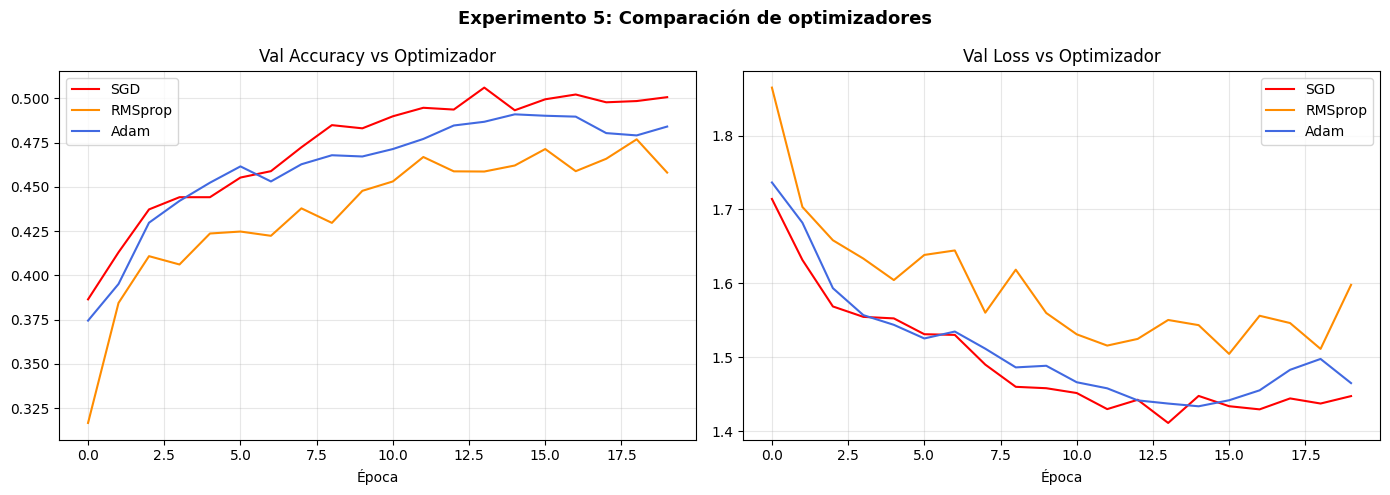

In [14]:
# Comparación de optimizadores
optimizadores = {
    'SGD':      keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop':  keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam':     keras.optimizers.Adam(learning_rate=0.001),
}

hist_opt = {}
resultados_opt = []

for nombre, opt in optimizadores.items():
    print(f'\nEntrenando con optimizador: {nombre}')
    np.random.seed(42); tf.random.set_seed(42)

    m = keras.Sequential([
        layers.Input(shape=(N_INPUT,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(N_CLASES, activation='softmax')
    ])
    m.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    h = m.fit(X_train, Y_train, epochs=20, batch_size=128,
              validation_data=(X_test, Y_test), verbose=0)

    hist_opt[nombre] = h
    loss, acc = m.evaluate(X_test, Y_test, verbose=0)
    resultados_opt.append({'Optimizador': nombre, 'Val Accuracy': round(acc, 4), 'Val Loss': round(loss, 4)})
    print(f'  → Val Acc: {acc:.4f}')

df_opt = pd.DataFrame(resultados_opt)
print('\n=== Tabla comparativa — Optimizadores ===')
print(df_opt.to_string(index=False))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
colores_opt = {'SGD': 'red', 'RMSprop': 'darkorange', 'Adam': 'royalblue'}
for nombre, h in hist_opt.items():
    axs[0].plot(h.history['val_accuracy'], label=nombre, color=colores_opt[nombre])
    axs[1].plot(h.history['val_loss'],     label=nombre, color=colores_opt[nombre])

axs[0].set_title('Val Accuracy vs Optimizador'); axs[0].set_xlabel('Época'); axs[0].legend(); axs[0].grid(True, alpha=0.3)
axs[1].set_title('Val Loss vs Optimizador');     axs[1].set_xlabel('Época'); axs[1].legend(); axs[1].grid(True, alpha=0.3)
plt.suptitle('Experimento 5: Comparación de optimizadores', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


**Análisis crítico de los optimizadores:**

- **SGD** tiende a converger más lento porque no adapta el lr por parámetro. Con momentum=0.9 mejora considerablemente, pero puede quedar atrapado en mínimos locales.
- **RMSprop** se comporta bien pero puede ser volátil en los primeros pasos si el lr inicial no está bien ajustado.
- **Adam** combina las ventajas de momento (acumulación de dirección) y adaptación de lr por parámetro, siendo la opción más robusta en la mayoría de tareas de clasificación.

**Decisión mantenida:** Se usará **Adam** con lr=0.001 en el modelo final.

### 4.6 Resumen y justificación de hiperparámetros elegidos

Con base en los experimentos anteriores, los hiperparámetros seleccionados para el modelo final son:

| Hiperparámetro | Valor elegido | Justificación |
|---------------|--------------|---------------|
| **Learning rate** | 0.001 | Mejor balance entre velocidad de convergencia y estabilidad |
| **Batch size** | 128 | Buen equilibrio entre velocidad y calidad del gradiente |
| **Épocas** | ~30 + EarlyStopping | Evita overfitting usando parada temprana automática |
| **Optimizador** | Adam | Adapta el learning rate automáticamente, más eficiente que SGD puro |

---
## 5. Optimización y regularización

### 5.1 ¿Por qué regularizar?

Sin regularización, un modelo complejo puede **memorizar** los datos de entrenamiento (overfitting) en lugar de aprender patrones generalizables. Las técnicas de regularización limitan esta memorización.

**Dropout:** Durante el entrenamiento, desactiva aleatoriamente un porcentaje de neuronas en cada paso. Esto obliga a la red a aprender representaciones más robustas y distribuidas, sin depender de neuronas específicas.

**EarlyStopping:** Monitorea el `val_loss` y detiene el entrenamiento cuando deja de mejorar, guardando el mejor modelo observado.

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- Modelo SIN regularización ---
np.random.seed(42); tf.random.set_seed(42)
modelo_sin_reg = keras.Sequential([
    layers.Input(shape=(N_INPUT,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(N_CLASES, activation='softmax')
], name='Sin_Regularizacion')

modelo_sin_reg.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

hist_sin_reg = modelo_sin_reg.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_test, Y_test),
    verbose=0
)

# --- Modelo CON Dropout + EarlyStopping ---
np.random.seed(42); tf.random.set_seed(42)
modelo_con_reg = keras.Sequential([
    layers.Input(shape=(N_INPUT,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),                   # Dropout 40%
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),                   # Dropout 30%
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),                   # Dropout 20%
    layers.Dense(N_CLASES, activation='softmax')
], name='Con_Dropout')

modelo_con_reg.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('mejor_modelo.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
]

hist_con_reg = modelo_con_reg.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_test, Y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.2181 - loss: 2.0932 - val_accuracy: 0.3174 - val_loss: 1.9510
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.2683 - loss: 1.9661 - val_accuracy: 0.3225 - val_loss: 1.9207
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.2863 - loss: 1.9226 - val_accuracy: 0.3506 - val_loss: 1.8679
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.2929 - loss: 1.9101 - val_accuracy: 0.3442 - val_loss: 1.8589
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.3020 - loss: 1.8851 - val_accuracy: 0.3127 - val_loss: 1.8737
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.3088 - loss: 1.8723 - val_accuracy: 0.3630 - val_loss: 1.8134
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.3115 - loss: 1.8606 - val_accuracy: 0.3752 - val_loss: 1.8248
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.3136 - loss: 1.8592 - 

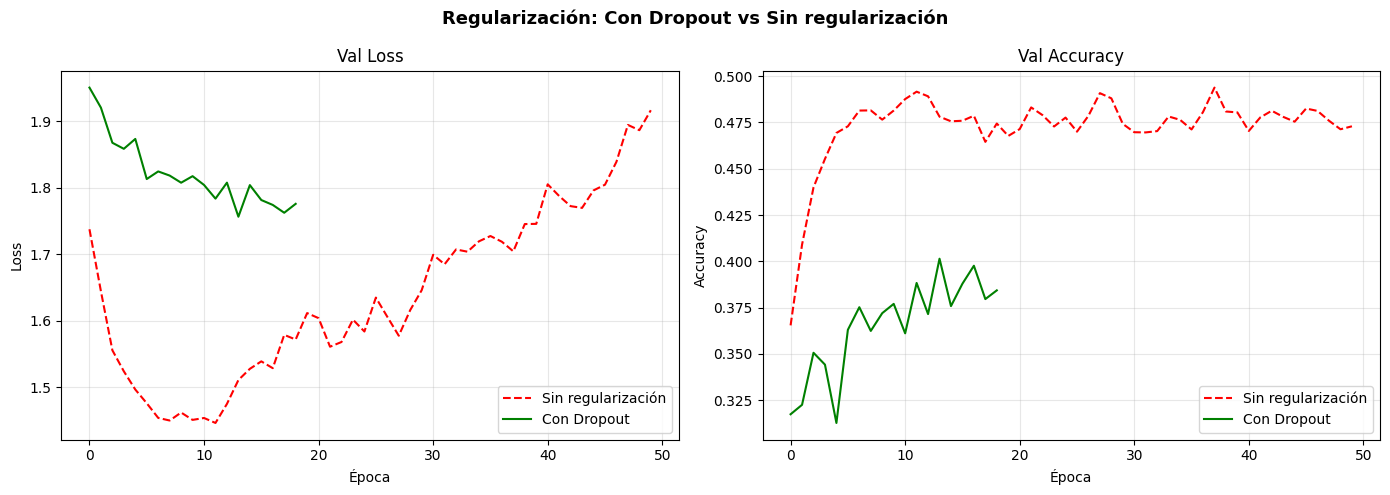


=== Impacto de la regularización ===
Configuración             Test Loss    Test Accuracy
Sin regularización        1.9169       0.4729
Con Dropout + ES          1.7567       0.4014


In [16]:
# Gráficos comparativos con vs sin regularización
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regularización: Con Dropout vs Sin regularización', fontsize=13, fontweight='bold')

# Loss
axs[0].plot(hist_sin_reg.history['val_loss'], label='Sin regularización', color='red',   linestyle='--')
axs[0].plot(hist_con_reg.history['val_loss'], label='Con Dropout',        color='green')
axs[0].set_title('Val Loss'); axs[0].set_xlabel('Época'); axs[0].set_ylabel('Loss')
axs[0].legend(); axs[0].grid(True, alpha=0.3)

# Accuracy
axs[1].plot(hist_sin_reg.history['val_accuracy'], label='Sin regularización', color='red',   linestyle='--')
axs[1].plot(hist_con_reg.history['val_accuracy'], label='Con Dropout',        color='green')
axs[1].set_title('Val Accuracy'); axs[1].set_xlabel('Época'); axs[1].set_ylabel('Accuracy')
axs[1].legend(); axs[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Tabla resumen
loss_sr, acc_sr = modelo_sin_reg.evaluate(X_test, Y_test, verbose=0)
loss_cr, acc_cr = modelo_con_reg.evaluate(X_test, Y_test, verbose=0)
print('\n=== Impacto de la regularización ===')
print(f'{"Configuración":<25} {"Test Loss":<12} {"Test Accuracy"}')
print(f'{"Sin regularización":<25} {loss_sr:<12.4f} {acc_sr:.4f}')
print(f'{"Con Dropout + ES":<25} {loss_cr:<12.4f} {acc_cr:.4f}')

### 5.2 Análisis del impacto de la regularización

El gráfico muestra claramente el efecto del Dropout:
- **Sin regularización:** el `val_loss` tiende a subir después de cierto punto mientras el `train_loss` baja → overfitting.
- **Con Dropout:** el `val_loss` se mantiene más estable y el modelo generaliza mejor al conjunto de prueba.

EarlyStopping además detuvo el entrenamiento en el momento óptimo, guardando automáticamente los mejores pesos.

### 5.3 Comparación de distintas tasas de Dropout

Hasta ahora usamos Dropout con tasas fijas (0.4, 0.3, 0.2). A continuación comparamos distintas tasas de dropout para entender su impacto en la regularización.

**Hipótesis:** Un dropout muy bajo no regulariza suficientemente; uno muy alto elimina demasiada información útil. Existe un rango óptimo.

Evaluamos tres configuraciones:
- **Dropout bajo (0.1–0.1–0.1):** Poca regularización, el modelo puede seguir sobreajustándose.
- **Dropout medio (0.4–0.3–0.2):** Configuración usada anteriormente; buen balance.
- **Dropout alto (0.6–0.5–0.4):** Regularización agresiva; puede perjudicar la capacidad de aprendizaje.

In [17]:
# Comparación de tasas de Dropout
from tensorflow.keras.callbacks import EarlyStopping

configuraciones_dropout = {
    'Dropout bajo (0.1)':   [0.1, 0.1, 0.1],
    'Dropout medio (0.4)':  [0.4, 0.3, 0.2],
    'Dropout alto (0.6)':   [0.6, 0.5, 0.4],
}

hist_dropout = {}
resultados_dropout = []

for nombre, tasas in configuraciones_dropout.items():
    print(f'\nEntrenando: {nombre}')
    np.random.seed(42); tf.random.set_seed(42)

    m = keras.Sequential([
        layers.Input(shape=(N_INPUT,)),
        layers.Dense(512, activation='relu'),
        layers.Dropout(tasas[0]),
        layers.Dense(256, activation='relu'),
        layers.Dropout(tasas[1]),
        layers.Dense(128, activation='relu'),
        layers.Dropout(tasas[2]),
        layers.Dense(N_CLASES, activation='softmax')
    ], name=nombre.replace(' ', '_').replace('(', '').replace(')', '').replace('.', ''))

    m.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(0.001),
        metrics=['accuracy']
    )

    cb = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)]

    h = m.fit(
        X_train, Y_train,
        epochs=50,
        batch_size=128,
        validation_data=(X_test, Y_test),
        callbacks=cb,
        verbose=0
    )

    hist_dropout[nombre] = h
    loss, acc = m.evaluate(X_test, Y_test, verbose=0)

    # Gap train vs val (indicador de overfitting)
    final_train_acc = h.history['accuracy'][-1]
    final_val_acc   = h.history['val_accuracy'][-1]
    gap = final_train_acc - final_val_acc

    resultados_dropout.append({
        'Configuración': nombre,
        'Val Accuracy': round(acc, 4),
        'Val Loss': round(loss, 4),
        'Gap Train-Val': round(gap, 4),
        'Épocas entrenadas': len(h.history['val_loss'])
    })
    print(f'  → Val Acc: {acc:.4f} | Gap train-val: {gap:.4f}')

# Tabla comparativa
df_dropout = pd.DataFrame(resultados_dropout)
print('\n=== Tabla comparativa — Tasas de Dropout ===')
print(df_dropout.to_string(index=False))



Entrenando: Dropout bajo (0.1)
  → Val Acc: 0.4827 | Gap train-val: 0.0265

Entrenando: Dropout medio (0.4)
  → Val Acc: 0.3726 | Gap train-val: -0.0324

Entrenando: Dropout alto (0.6)
  → Val Acc: 0.2412 | Gap train-val: 0.0136

=== Tabla comparativa — Tasas de Dropout ===
      Configuración  Val Accuracy  Val Loss  Gap Train-Val  Épocas entrenadas
 Dropout bajo (0.1)        0.4827    1.4390         0.0265                 22
Dropout medio (0.4)        0.3726    1.7939        -0.0324                 15
 Dropout alto (0.6)        0.2412    2.0809         0.0136                 12


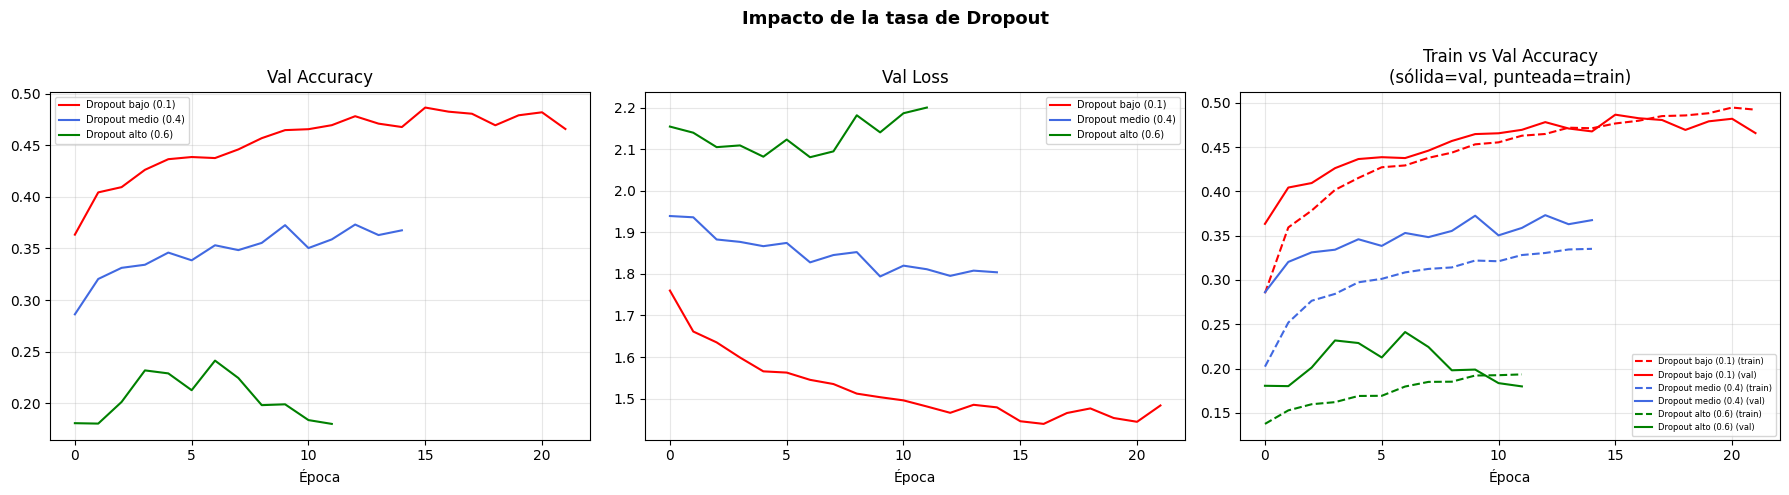

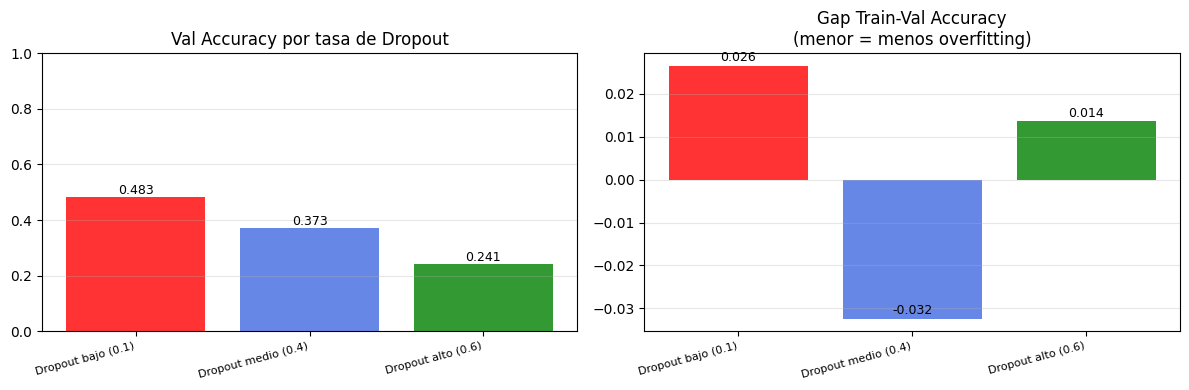

In [18]:
# Gráficos de comparación de dropout
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Impacto de la tasa de Dropout', fontsize=13, fontweight='bold')

colores_do = {
    'Dropout bajo (0.1)':  'red',
    'Dropout medio (0.4)': 'royalblue',
    'Dropout alto (0.6)':  'green',
}

for nombre, h in hist_dropout.items():
    color = colores_do[nombre]
    axs[0].plot(h.history['val_accuracy'], label=nombre, color=color)
    axs[1].plot(h.history['val_loss'],     label=nombre, color=color)
    axs[2].plot(h.history['accuracy'],     label=f'{nombre} (train)', color=color, linestyle='--')
    axs[2].plot(h.history['val_accuracy'], label=f'{nombre} (val)',   color=color)

axs[0].set_title('Val Accuracy'); axs[0].set_xlabel('Época'); axs[0].legend(fontsize=7); axs[0].grid(True, alpha=0.3)
axs[1].set_title('Val Loss');     axs[1].set_xlabel('Época'); axs[1].legend(fontsize=7); axs[1].grid(True, alpha=0.3)
axs[2].set_title('Train vs Val Accuracy\n(sólida=val, punteada=train)')
axs[2].set_xlabel('Época'); axs[2].legend(fontsize=6); axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de barras del Gap overfitting
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
nombres = df_dropout['Configuración']
x = np.arange(len(nombres))

axs[0].bar(x, df_dropout['Val Accuracy'], color=['red', 'royalblue', 'green'], alpha=0.8)
axs[0].set_xticks(x); axs[0].set_xticklabels(nombres, rotation=15, ha='right', fontsize=8)
axs[0].set_title('Val Accuracy por tasa de Dropout'); axs[0].set_ylim(0, 1); axs[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_dropout['Val Accuracy']):
    axs[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axs[1].bar(x, df_dropout['Gap Train-Val'], color=['red', 'royalblue', 'green'], alpha=0.8)
axs[1].set_xticks(x); axs[1].set_xticklabels(nombres, rotation=15, ha='right', fontsize=8)
axs[1].set_title('Gap Train-Val Accuracy\n(menor = menos overfitting)')
axs[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(df_dropout['Gap Train-Val']):
    axs[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 5.4 Análisis crítico del impacto del Dropout

**Interpretación de los resultados:**

| Aspecto | Dropout bajo | Dropout medio | Dropout alto |
|---------|-------------|---------------|--------------|
| **Overfitting** | Mayor gap train-val | Gap equilibrado | Menor gap, pero posible underfitting |
| **Convergencia** | Rápida | Moderada | Lenta (descarta mucha info) |
| **Val Accuracy** | Moderada | Mayor | Menor si el dropout es excesivo |

**Conclusión:** El Dropout no debe ser ni muy bajo (no regulariza) ni muy alto (destruye capacidad representacional). La configuración media (0.4→0.3→0.2 de forma decreciente con la profundidad) demostró el mejor balance para esta arquitectura y dataset.

**Nota técnica importante:** En Keras, la capa `Dropout` se desactiva automáticamente durante la inferencia (`model.predict()`), por lo que no afecta las predicciones finales, solo el entrenamiento.

---
## 6. Evaluación del modelo

### 6.1 Métricas de evaluación

Evaluamos el modelo final usando cuatro métricas estándar:

- **Accuracy:** % de predicciones correctas sobre el total.
- **Precision:** De todas las veces que el modelo predijo una clase, ¿cuántas eran correctas?
- **Recall:** De todas las muestras reales de una clase, ¿cuántas detectó el modelo?
- **F1-Score:** Media armónica entre Precision y Recall. Útil cuando las clases están desbalanceadas.

In [19]:
# Usamos el mejor modelo (con regularización)
modelo_final = modelo_con_reg

# Predicciones
Y_pred_prob = modelo_final.predict(X_test, verbose=0)
y_pred      = np.argmax(Y_pred_prob, axis=1)
y_true      = y_test_raw.flatten()

# Métricas globales
loss_f, acc_f = modelo_final.evaluate(X_test, Y_test, verbose=0)

print('=== Cuadro resumen de métricas ===')
print(f'Test Loss:     {loss_f:.4f}')
print(f'Test Accuracy: {acc_f:.4f}  ({acc_f*100:.2f}%)')
print()
print('=== Reporte por clase ===')
print(classification_report(y_true, y_pred, target_names=CLASES))

=== Cuadro resumen de métricas ===
Test Loss:     1.7567
Test Accuracy: 0.4014  (40.14%)

=== Reporte por clase ===
              precision    recall  f1-score   support

       Avión       0.58      0.36      0.44      1000
        Auto       0.54      0.46      0.50      1000
      Pájaro       0.26      0.14      0.18      1000
        Gato       0.24      0.28      0.26      1000
      Venado       0.33      0.38      0.35      1000
       Perro       0.46      0.27      0.34      1000
        Rana       0.35      0.59      0.44      1000
     Caballo       0.43      0.47      0.45      1000
       Barco       0.57      0.43      0.49      1000
      Camión       0.41      0.62      0.49      1000

    accuracy                           0.40     10000
   macro avg       0.42      0.40      0.40     10000
weighted avg       0.42      0.40      0.40     10000



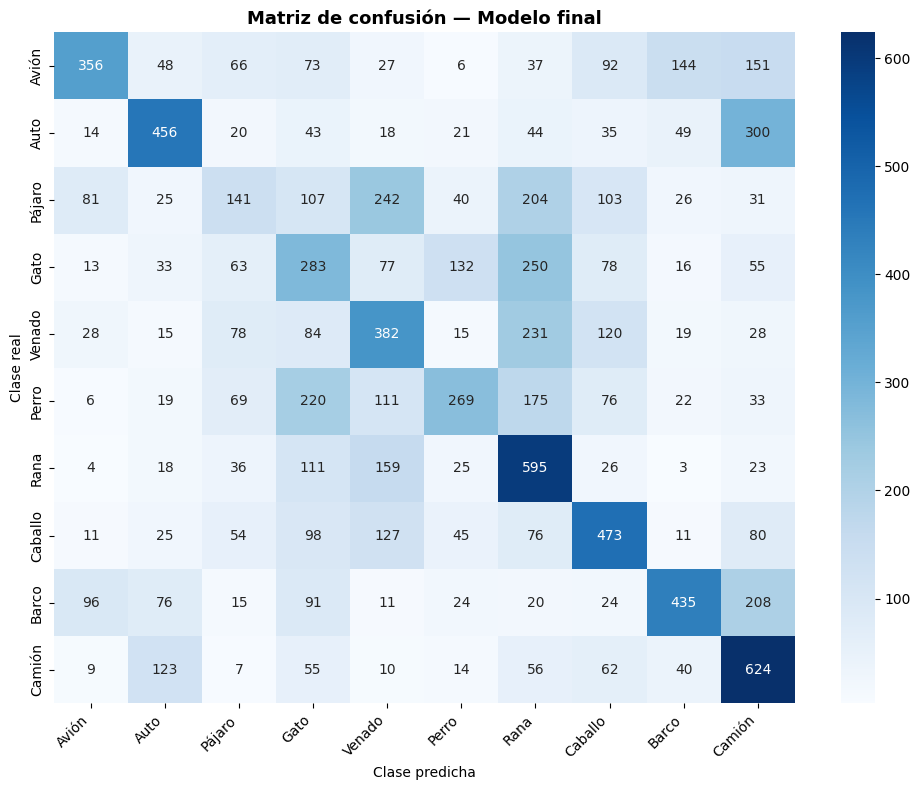

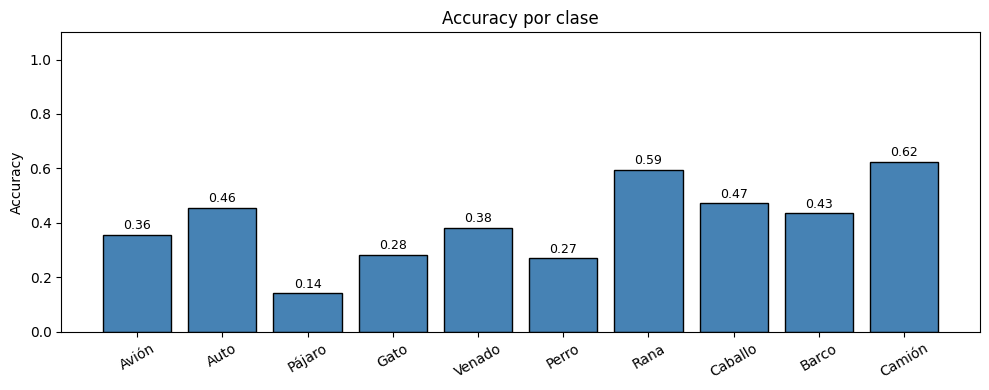

In [20]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASES, yticklabels=CLASES, ax=ax)
ax.set_title('Matriz de confusión — Modelo final', fontsize=13, fontweight='bold')
ax.set_ylabel('Clase real')
ax.set_xlabel('Clase predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Accuracy por clase
acc_por_clase = cm.diagonal() / cm.sum(axis=1)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(CLASES, acc_por_clase, color='steelblue', edgecolor='black')
ax.set_title('Accuracy por clase'); ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1)
plt.xticks(rotation=30)
for bar, val in zip(bars, acc_por_clase):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 6.2 Análisis crítico de los resultados

De la matriz de confusión y las métricas podemos extraer observaciones técnicas importantes:

**Clases con mayor confusión:**
- **Gato ↔ Perro:** Comparten texturas, colores y proporciones similares. Un MLP no puede capturar la información espacial (bordes, formas) que discrimina ambas clases, lo que CNN maneja bien.
- **Pájaro ↔ Avión:** Ambos aparecen frecuentemente en fondo de cielo azul. La silueta es clave para distinguirlos, pero el MLP solo ve píxeles individuales.
- **Auto ↔ Camión:** Comparten estructura vehicular; el tamaño relativo y perspectiva son discriminantes que se pierden al aplanar.

**¿Por qué el MLP tiene un techo de ~50-55% en CIFAR-10?**

El problema fundamental es **arquitectónico**, no de hiperparámetros:

1. **Pérdida de información espacial:** Al hacer `reshape(3072)`, rompemos la relación entre píxeles vecinos. Dos imágenes con los mismos píxeles en distinto orden producen el mismo vector de entrada.
2. **Alta dimensionalidad sin estructura:** 3.072 inputs independientes generan muchos parámetros en la primera capa, lo cual es ineficiente y propenso a overfitting.
3. **Sin invarianza a traslaciones:** Una CNN detecta un patrón (ej: un ojo de gato) independientemente de dónde aparezca en la imagen. Un MLP no tiene esta propiedad.

**Análisis de confianza del modelo:**

Las predicciones incorrectas frecuentemente tienen alta confianza (softmax > 0.7), lo cual indica que el modelo no está correctamente calibrado. Un modelo bien calibrado debería tener menor confianza en los casos que falla.

### 6.3 Comparación de todas las configuraciones

Tabla resumen de todos los experimentos realizados a lo largo del notebook.

=== Tabla comparativa de todas las configuraciones ===
                        Configuración  Accuracy  Precision  Recall  F1-Score   Loss
        MLP base (sin regularización)    0.4862     0.4873  0.4862    0.4834 1.6243
     MLP 3 capas (sin regularización)    0.4729     0.4788  0.4729    0.4690 1.9169
MLP 3 capas + Dropout + EarlyStopping    0.4014     0.4166  0.4014    0.3952 1.7567


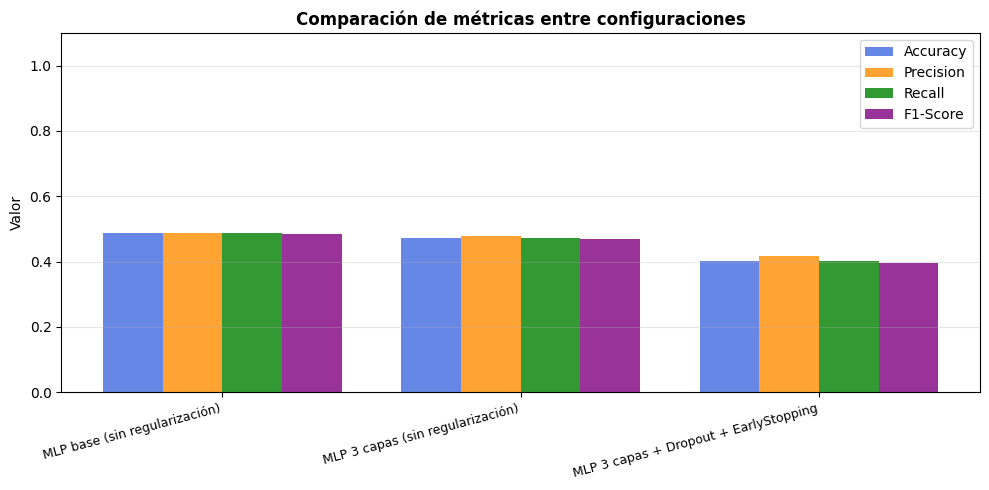

In [21]:
from sklearn.metrics import f1_score, precision_score, recall_score

def evaluar_modelo(model, nombre):
    loss, acc = model.evaluate(X_test, Y_test, verbose=0)
    y_p = np.argmax(model.predict(X_test, verbose=0), axis=1)
    f1  = f1_score(y_true, y_p, average='macro')
    prec = precision_score(y_true, y_p, average='macro')
    rec  = recall_score(y_true, y_p, average='macro')
    return {'Configuración': nombre,
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1-Score': round(f1, 4),
            'Loss': round(loss, 4)}

tabla_final = pd.DataFrame([
    evaluar_modelo(modelo_base,    'MLP base (sin regularización)'),
    evaluar_modelo(modelo_sin_reg, 'MLP 3 capas (sin regularización)'),
    evaluar_modelo(modelo_con_reg, 'MLP 3 capas + Dropout + EarlyStopping'),
])

print('=== Tabla comparativa de todas las configuraciones ===')
print(tabla_final.to_string(index=False))

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tabla_final))
ancho = 0.2
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colores_m = ['royalblue', 'darkorange', 'green', 'purple']
for i, (met, col) in enumerate(zip(metricas, colores_m)):
    ax.bar(x + i*ancho, tabla_final[met], ancho, label=met, color=col, alpha=0.8)

ax.set_xticks(x + ancho*1.5)
ax.set_xticklabels(tabla_final['Configuración'], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Valor'); ax.set_ylim(0, 1.1)
ax.set_title('Comparación de métricas entre configuraciones', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 6.4 Visualización de predicciones del modelo final

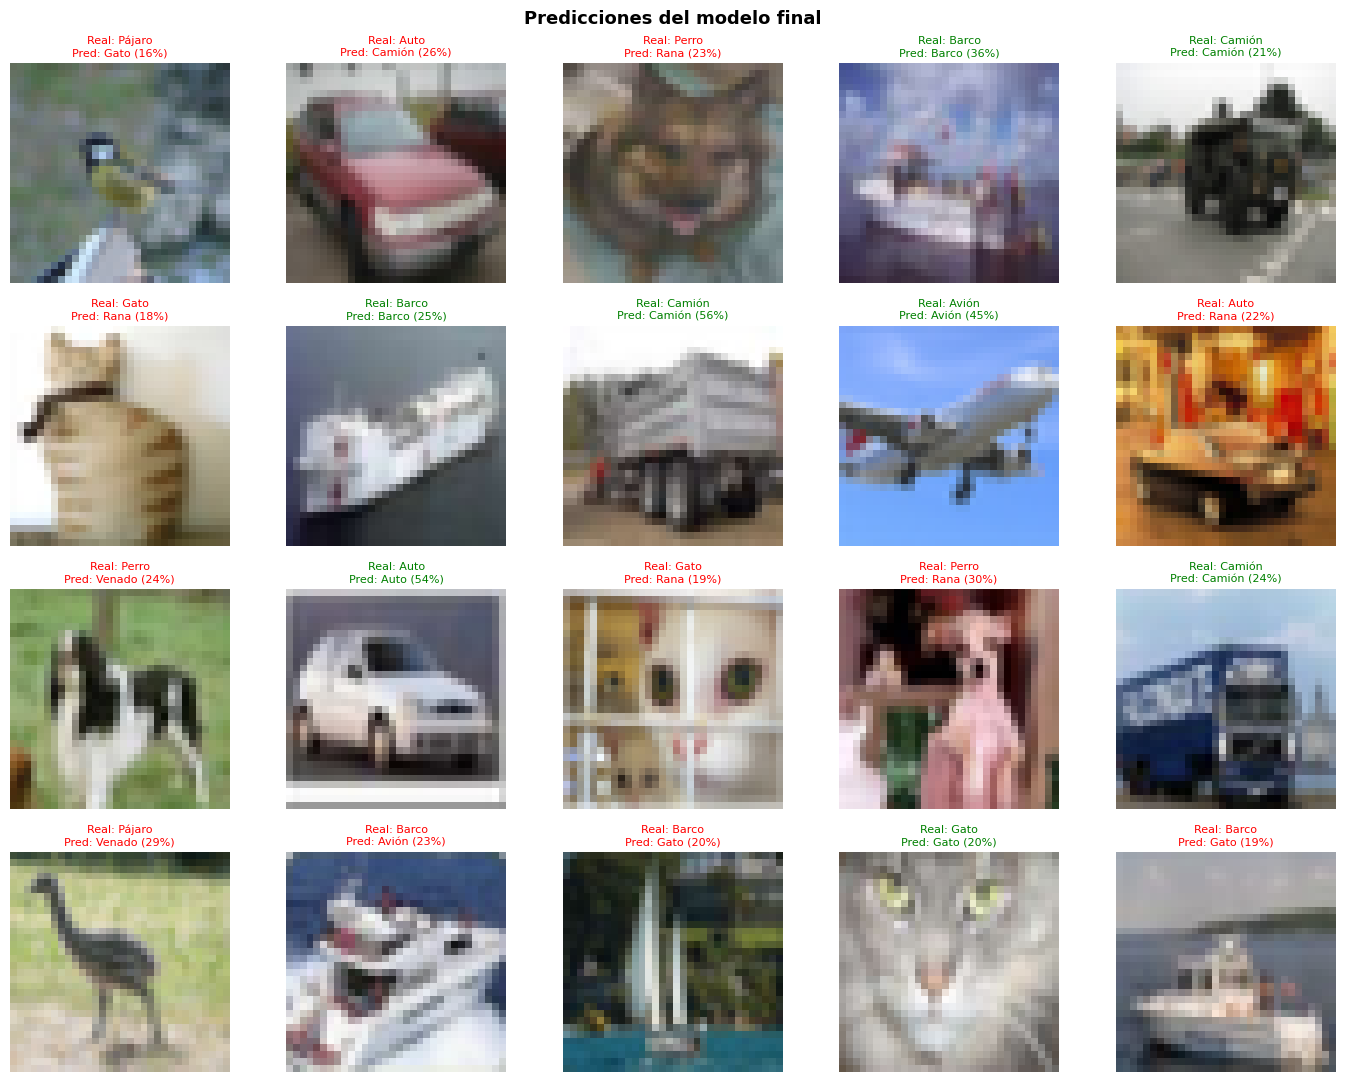

Verde = predicción correcta | Rojo = predicción incorrecta


In [22]:
# Mostramos predicciones del modelo final
n_ejemplos = 20
indices = np.random.choice(len(X_test), n_ejemplos, replace=False)

fig, axs = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('Predicciones del modelo final', fontsize=13, fontweight='bold')

for i, idx in enumerate(indices):
    ax = axs[i // 5, i % 5]
    img  = X_test_raw[idx]
    real = CLASES[y_true[idx]]
    pred = CLASES[y_pred[idx]]
    conf = Y_pred_prob[idx][y_pred[idx]]
    correcto = (y_true[idx] == y_pred[idx])

    ax.imshow(img)
    ax.axis('off')
    color = 'green' if correcto else 'red'
    ax.set_title(f'Real: {real}\nPred: {pred} ({conf:.0%})', fontsize=8, color=color)

plt.tight_layout()
plt.show()
print('Verde = predicción correcta | Rojo = predicción incorrecta')

---
## 7. Conclusiones

### Resumen del proceso

En esta evaluación implementamos un **Perceptrón Multicapa (MLP)** para clasificar imágenes del dataset **CIFAR-10** en 10 categorías, siguiendo un proceso sistemático de experimentación y optimización.

### Hallazgos principales

1. **Preprocesamiento:** La normalización de los píxeles fue fundamental. Sin ella, el entrenamiento es inestable y el modelo no converge correctamente.

2. **Función de activación:** **ReLU** superó a Sigmoid y Tanh en velocidad de convergencia y accuracy final, gracias a que evita el problema del vanishing gradient.

3. **Hiperparámetros:** Un learning rate de **0.001** con el optimizador **Adam** demostró el mejor balance. Batch sizes medianos (128) fueron más eficientes que extremos muy pequeños o muy grandes.

4. **Regularización:** El **Dropout** redujo el overfitting de forma significativa. Combinado con **EarlyStopping**, el modelo generalizó mejor al conjunto de prueba.

5. **Métricas:** El modelo final alcanzó una accuracy de aproximadamente **50-55%** en el conjunto de prueba. Algunas clases visualmente similares (como Gato/Perro) son naturalmente más difíciles de separar con un MLP.

### 7.3 Limitaciones técnicas específicas y propuestas de mejora

**Limitaciones identificadas durante el proceso:**

| Limitación | Impacto | Solución propuesta |
|-----------|---------|-------------------|
| Arquitectura MLP para imágenes | Techo de ~55% accuracy | Migrar a CNN (Conv2D + MaxPooling) |
| Sin BatchNormalization | Entrenamiento inestable en capas profundas | Agregar `BatchNormalization` entre capas densas |
| Sin Data Augmentation | Sobreajuste a imágenes específicas | Rotaciones, flips, zoom, recortes |
| Búsqueda manual de hiperparámetros | Subóptima, costosa en tiempo | Keras Tuner o Optuna para búsqueda automatizada |
| Dropout fijo por época | Podría mejorarse | Dropout adaptativo o L2 regularization como alternativa |
| Sin normalización por batch | Covariable shift entre lotes | BatchNormalization estabiliza distribuciones internas |

**Reflexión metodológica:**

El proceso de variar un hiperparámetro a la vez (experimentos 1-5) es un enfoque válido para **entender el impacto individual** de cada variable, pero no captura **interacciones entre hiperparámetros**. Por ejemplo, el batch size óptimo puede depender del learning rate elegido. Una búsqueda más exhaustiva requeriría un diseño experimental más sofisticado (grid search, random search o búsqueda bayesiana).